# Part 5 — Per-niche Gaussian Graphical Models

**Question.** Do niches that are biologically similar (in Part 2's composition + recurrence sense) also produce similar gene networks (in Part 4's GGM sense)? Or do gene networks capture something orthogonal to cell composition?

**Approach.** Apply Part 4's GGM machinery, but at the niche level instead of cell-type level. Fit a Graphical Lasso per niche on a balanced subsample of training cells assigned to that niche, on the same 378 common genes and same α=0.07. Then compare gene networks across the 20 niches via Jaccard overlap and hierarchical clustering.

**Notebook structure.**

1. §0 Setup + load artifacts
2. §1 Per-niche cell subsampling
3. §2 Fit per-niche GGMs (20 fits)
4. §3 Per-niche network properties
5. §4 Niche-to-niche network distance + cross-comparison with Part 2 composition
6. §5 Spatial / biological coherence (patient distribution, dominant class)
7. §6 Summary

In [1]:
import sys
import importlib
import time
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Path setup
ROOT = Path.cwd()
if (ROOT / "src").is_dir():
    sys.path.insert(0, str(ROOT / "src"))
elif (ROOT.parent / "src").is_dir():
    sys.path.insert(0, str(ROOT.parent / "src"))

import data_io
import preprocessing
import splits as splits_mod
import ggm
importlib.reload(data_io)
importlib.reload(preprocessing)
importlib.reload(splits_mod)
importlib.reload(ggm)

CACHE_DIR = "cache" if (ROOT / "cache").is_dir() else "../cache"
G = data_io.load_global(CACHE_DIR)
print(f"globals loaded: {G.n_cells:,} cells")

# Splits + HVG + niche outputs
split = splits_mod.load_splits(f"{CACHE_DIR}/splits/patient_split.json")
prep_cache = Path(CACHE_DIR) / "preprocessing"
hvg_idx = preprocessing.load_hvg(prep_cache)

# Load niche assignments per cell (from Part 2)
niche_per_cell = np.load(f"{CACHE_DIR}/communities/niche_per_cell.npy")
print(f"niche assignments: shape {niche_per_cell.shape}, "
      f"-1 (unassigned) count = {(niche_per_cell == -1).sum():,}")
print(f"  assigned: {(niche_per_cell != -1).sum():,} cells ({(niche_per_cell != -1).mean():.1%})")

# Niche centroids (from Part 2)
niche_centroids = pd.read_parquet(f"{CACHE_DIR}/communities/niche_centroids.parquet")
print(f"\nniche centroids: {niche_centroids.shape}")
print(niche_centroids[["dominant_class", "dominant_frac", "n_communities", "n_patients"]].head(20))

globals loaded: 8,065,561 cells
niche assignments: shape (8065561,), -1 (unassigned) count = 1,855,878
  assigned: 6,209,683 cells (77.0%)

niche centroids: (20, 15)
          dominant_class  dominant_frac  n_communities  n_patients
niche_id                                                          
1                      7       0.815951           1105          48
0                      7       0.951328            982          45
16                     0       0.788656            856          39
2                      7       0.649497            853          52
4                      7       0.455479            705          53
19                     0       0.528929            538          43
7                      4       0.531387            487          34
13                     3       0.264655            462          48
5                      4       0.876570            425          22
12                     2       0.469599            386          39
3                      2      

In [2]:
# Load gene names
gene_names_df = pd.read_csv(ROOT.parent / "data" / "gene_names.csv" if (ROOT.parent / "data").is_dir() else ROOT / "data" / "gene_names.csv", index_col=0)
gene_names_df.columns = ["symbol"]
gene_names_arr = gene_names_df["symbol"].values

# Load common gene indices from Part 4
ggm_cache = Path(CACHE_DIR) / "ggm"
common_gene_idxs_within_hvg = np.load(ggm_cache / "common_gene_idxs.npy")
common_gene_global = np.load(ggm_cache / "common_gene_global.npy")
common_gene_symbols = gene_names_arr[common_gene_global]
n_common = len(common_gene_symbols)
print(f"common genes from Part 4: {n_common}")

# Load the per-class GGMs from Part 4 for later comparison
with open(ggm_cache / "ggms_alpha_007_common378.pkl", "rb") as f:
    part4_ggms = pickle.load(f)
print(f"loaded Part 4 GGMs (8 classes, α={part4_ggms['alpha']})")

# Set up Part 5 cache
ggm5_cache = Path(CACHE_DIR) / "ggm_niches"
ggm5_cache.mkdir(exist_ok=True, parents=True)
print(f"Part 5 cache dir: {ggm5_cache}")

common genes from Part 4: 378
loaded Part 4 GGMs (8 classes, α=0.07)
Part 5 cache dir: ../cache/ggm_niches


## 1. Per-niche cell subsampling

For each of the 20 niches, gather training-patient + in_mask cells assigned to that niche. Target 5,000 cells per niche, patient-stratified within niche.

Note: niches are stratified by patient (Part 2 showed graded recurrence). Rare niches (5, 15) come from a subset of patients only.

In [3]:
# Diagnose how many cells each niche has in the training pool
N_NICHES = 20
SUBSAMPLE_PER_NICHE = 5000

train_mask = np.isin(G.patient, split.train) & G.train_mask & (niche_per_cell != -1)
print(f"Training-pool cells assigned to a niche: {train_mask.sum():,}")
print()

for nid in range(N_NICHES):
    is_n = train_mask & (niche_per_cell == nid)
    n_total = is_n.sum()
    n_patients = len(np.unique(G.patient[is_n])) if n_total > 0 else 0
    cap_at = min(SUBSAMPLE_PER_NICHE, n_total)
    dom_class = int(niche_centroids.loc[nid, "dominant_class"]) if nid in niche_centroids.index else -1
    n_pat_centroid = int(niche_centroids.loc[nid, "n_patients"]) if nid in niche_centroids.index else 0
    print(f"  niche {nid:>2d} (dom_c{dom_class}, in {n_pat_centroid} pats): "
          f"{n_total:>7,} train cells from {n_patients:>2d} pats → subsample {cap_at:,}")

Training-pool cells assigned to a niche: 3,624,238

  niche  0 (dom_c7, in 45 pats): 343,684 train cells from 32 pats → subsample 5,000
  niche  1 (dom_c7, in 48 pats): 363,508 train cells from 34 pats → subsample 5,000
  niche  2 (dom_c7, in 52 pats): 244,462 train cells from 36 pats → subsample 5,000
  niche  3 (dom_c2, in 42 pats): 114,365 train cells from 29 pats → subsample 5,000
  niche  4 (dom_c7, in 53 pats): 242,994 train cells from 37 pats → subsample 5,000
  niche  5 (dom_c4, in 22 pats):  95,960 train cells from 16 pats → subsample 5,000
  niche  6 (dom_c4, in 25 pats):  53,370 train cells from 18 pats → subsample 5,000
  niche  7 (dom_c4, in 34 pats): 128,892 train cells from 22 pats → subsample 5,000
  niche  8 (dom_c3, in 23 pats):  78,757 train cells from 14 pats → subsample 5,000
  niche  9 (dom_c2, in 37 pats): 225,589 train cells from 26 pats → subsample 5,000
  niche 10 (dom_c2, in 44 pats): 106,049 train cells from 30 pats → subsample 5,000
  niche 11 (dom_c1, in 4

In [7]:
importlib.reload(ggm)

print(f"subsampling {SUBSAMPLE_PER_NICHE:,} cells per niche...")
t0 = time.time()
niche_subsamples = ggm.subsample_cells_per_label(
    G=G,
    labels=niche_per_cell,
    train_patients=split.train,
    in_mask=G.train_mask,
    n_per_label=SUBSAMPLE_PER_NICHE,
    seed=42,
    label_values=list(range(N_NICHES)),
)
print(f"  done in {time.time()-t0:.1f}s\n")

# Inspect
for nid in range(N_NICHES):
    n_chosen = len(niche_subsamples[nid])
    if n_chosen > 0:
        chosen_patients = np.unique(G.patient[niche_subsamples[nid]])
        print(f"  niche {nid:>2d}: {n_chosen:,} cells from {len(chosen_patients):>2d} patients")

subsampling 5,000 cells per niche...
  done in 0.2s

  niche  0: 5,000 cells from 32 patients
  niche  1: 5,000 cells from 34 patients
  niche  2: 5,000 cells from 36 patients
  niche  3: 5,000 cells from 29 patients
  niche  4: 5,000 cells from 37 patients
  niche  5: 5,000 cells from 16 patients
  niche  6: 5,000 cells from 18 patients
  niche  7: 5,000 cells from 22 patients
  niche  8: 5,000 cells from 14 patients
  niche  9: 5,000 cells from 26 patients
  niche 10: 5,000 cells from 30 patients
  niche 11: 5,000 cells from 30 patients
  niche 12: 5,000 cells from 28 patients
  niche 13: 5,000 cells from 33 patients
  niche 14: 5,000 cells from 14 patients
  niche 15: 5,000 cells from  7 patients
  niche 16: 5,000 cells from 30 patients
  niche 17: 5,000 cells from 20 patients
  niche 18: 5,000 cells from 25 patients
  niche 19: 5,000 cells from 31 patients


In [8]:
# Load HVG matrix (33 GB), index into it for the niche subsamples
import torch
import datasets as gnn_datasets

cohort_path = Path(CACHE_DIR) / "gnn" / "cohort_hvg.pt"
print(f"loading {cohort_path}...")
t0 = time.time()
data_hvg = gnn_datasets.load_cohort_data(cohort_path)
print(f"  loaded in {time.time()-t0:.1f}s")

# Build per-niche common-gene matrices (using same 378 common genes from Part 4)
niche_X_common = {}
for nid in range(N_NICHES):
    cells = niche_subsamples[nid]
    if len(cells) == 0:
        continue
    X = data_hvg.x[cells].numpy()                              # (5000, 1000)
    X_common = X[:, common_gene_idxs_within_hvg]                # (5000, 378)
    niche_X_common[nid] = X_common

del data_hvg

print(f"\nPer-niche common-gene matrices ({n_common} genes):")
for nid in range(N_NICHES):
    if nid not in niche_X_common:
        continue
    X = niche_X_common[nid]
    print(f"  niche {nid:>2d}: shape {X.shape}, "
          f"mean {X.mean():+.3f}, std {X.std():.3f}, "
          f"min gene std {X.std(axis=0).min():.3f}")

loading ../cache/gnn/cohort_hvg.pt...
  loaded in 5.0s

Per-niche common-gene matrices (378 genes):
  niche  0: shape (5000, 378), mean -0.054, std 0.517, min gene std 0.000
  niche  1: shape (5000, 378), mean -0.050, std 0.507, min gene std 0.000
  niche  2: shape (5000, 378), mean -0.043, std 0.578, min gene std 0.000
  niche  3: shape (5000, 378), mean -0.028, std 0.696, min gene std 0.000
  niche  4: shape (5000, 378), mean -0.031, std 0.661, min gene std 0.000
  niche  5: shape (5000, 378), mean -0.044, std 0.530, min gene std 0.000
  niche  6: shape (5000, 378), mean -0.008, std 0.914, min gene std 0.000
  niche  7: shape (5000, 378), mean -0.028, std 0.675, min gene std 0.000
  niche  8: shape (5000, 378), mean +0.020, std 1.165, min gene std 0.000
  niche  9: shape (5000, 378), mean +0.033, std 1.098, min gene std 0.000
  niche 10: shape (5000, 378), mean +0.018, std 1.066, min gene std 0.000
  niche 11: shape (5000, 378), mean +0.003, std 0.842, min gene std 0.000
  niche 12: 

## 2. Fit per-niche GGMs

α=0.07 on 378 common genes, same as Part 4. `drop_low_var_genes=False` to keep all 378 genes in every niche (with min_std=0.05 floor in standardization). Some genes will have effectively zero precision rows in niches where they're silent — that's correct behavior.

In [9]:
ALPHA = 0.07
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

print(f"Fitting GLasso at α={ALPHA} for {N_NICHES} niches on {n_common} common genes\n")

niche_ggms = {}
t_total = time.time()
for nid in range(N_NICHES):
    print(f"  niche {nid:>2d}...", end=" ", flush=True)
    t0 = time.time()
    fit = ggm.fit_glasso(
        niche_X_common[nid],
        alpha=ALPHA,
        max_iter=200,
        min_std=0.05,
        drop_low_var_genes=False,
    )
    fit["partial_corr"] = ggm.precision_to_partial_corr(fit["precision_"])
    fit["degree"] = ggm.network_degree(fit["precision_"])
    niche_ggms[nid] = fit
    elapsed = time.time() - t0
    print(f"sparsity {fit['sparsity']:.4f}, "
          f"n_edges {fit['n_edges']:>5d}, "
          f"iters {fit['n_iter']}{'' if fit['converged'] else ' (NOT conv)'} | {elapsed:.0f}s")

print(f"\ntotal: {(time.time()-t_total)/60:.1f} min")

Fitting GLasso at α=0.07 for 20 niches on 378 common genes

  niche  0... sparsity 0.0106, n_edges   753, iters 28 | 5s
  niche  1... sparsity 0.0144, n_edges  1023, iters 21 | 4s
  niche  2... sparsity 0.0142, n_edges  1013, iters 4 | 1s
  niche  3... sparsity 0.0127, n_edges   908, iters 6 | 1s
  niche  4... sparsity 0.0153, n_edges  1087, iters 4 | 1s
  niche  5... sparsity 0.0088, n_edges   629, iters 15 | 3s
  niche  6... sparsity 0.0147, n_edges  1046, iters 20 | 4s
  niche  7... sparsity 0.0146, n_edges  1043, iters 44 | 7s
  niche  8... sparsity 0.0140, n_edges  1001, iters 9 | 2s
  niche  9... sparsity 0.0111, n_edges   793, iters 200 (NOT conv) | 32s
  niche 10... sparsity 0.0136, n_edges   970, iters 15 | 3s
  niche 11... sparsity 0.0134, n_edges   954, iters 6 | 1s
  niche 12... sparsity 0.0104, n_edges   738, iters 5 | 1s
  niche 13... sparsity 0.0142, n_edges  1010, iters 4 | 1s
  niche 14... sparsity 0.0090, n_edges   643, iters 5 | 1s
  niche 15... sparsity 0.0109, n_ed

In [10]:
# Inspect how many genes were dropped per niche
print(f"{'niche':<6s} {'dom':<5s} {'n_pats':<7s} {'n_edges':<8s} {'silent':<7s} {'lowvar':<7s} {'kept':<6s}")
print("-" * 50)
for nid in range(N_NICHES):
    g = niche_ggms[nid]
    dom = int(niche_centroids.loc[nid, "dominant_class"])
    n_pat = int(niche_centroids.loc[nid, "n_patients"])
    print(f"{nid:<6d} c{dom:<4d} {n_pat:<7d} {g['n_edges']:<8d} "
          f"{g['n_silent_genes']:<7d} {g['n_lowvar_genes']:<7d} {g['n_kept_genes']:<6d}")

niche  dom   n_pats  n_edges  silent  lowvar  kept  
--------------------------------------------------
0      c7    45      753      18      0       360   
1      c7    48      1023     16      0       362   
2      c7    52      1013     10      0       368   
3      c2    42      908      7       0       371   
4      c7    53      1087     15      0       363   
5      c4    22      629      32      0       346   
6      c4    25      1046     17      0       361   
7      c4    34      1043     15      0       363   
8      c3    23      1001     14      0       364   
9      c2    37      793      10      0       368   
10     c2    44      970      12      0       366   
11     c1    41      954      11      0       367   
12     c2    39      738      9       0       369   
13     c3    48      1010     10      0       368   
14     c5    24      643      15      0       363   
15     c5    11      775      24      0       354   
16     c0    39      989      9       0       36

In [11]:
# Save niche GGMs
niche_ggm_file = ggm5_cache / "niche_ggms_alpha_007_common378.pkl"
to_save = {
    "alpha": ALPHA,
    "n_genes": n_common,
    "common_gene_idxs_within_hvg": common_gene_idxs_within_hvg,
    "common_gene_global": common_gene_global,
    "per_niche": {
        nid: {
            "precision_": niche_ggms[nid]["precision_"],
            "partial_corr": niche_ggms[nid]["partial_corr"],
            "degree": niche_ggms[nid]["degree"],
            "n_edges": niche_ggms[nid]["n_edges"],
            "sparsity": niche_ggms[nid]["sparsity"],
            "n_iter": niche_ggms[nid]["n_iter"],
            "converged": niche_ggms[nid]["converged"],
            "n_silent_genes": niche_ggms[nid]["n_silent_genes"],
            "n_kept_genes": niche_ggms[nid]["n_kept_genes"],
            "silent_genes": niche_ggms[nid]["silent_genes"],
        }
        for nid in range(N_NICHES)
    },
}
with open(niche_ggm_file, "wb") as f:
    pickle.dump(to_save, f)
print(f"saved {niche_ggm_file} ({niche_ggm_file.stat().st_size/1e6:.1f} MB)")

saved ../cache/ggm_niches/niche_ggms_alpha_007_common378.pkl (45.8 MB)


In [12]:
# Per-niche network summary table (combining everything)
summary_rows = []
for nid in range(N_NICHES):
    g = niche_ggms[nid]
    deg = g["degree"]
    dom = int(niche_centroids.loc[nid, "dominant_class"])
    n_pat = int(niche_centroids.loc[nid, "n_patients"])
    summary_rows.append({
        "niche": nid,
        "dom_class": dom,
        "n_pat": n_pat,
        "n_edges": g["n_edges"],
        "n_silent": g["n_silent_genes"],
        "n_kept": g["n_kept_genes"],
        "edges_per_kept": g["n_edges"] / g["n_kept_genes"],
        "mean_deg_kept": deg[deg > 0].mean() if (deg > 0).any() else 0.0,
        "max_deg": int(deg.max()),
        "frac_isolated_kept": (deg == 0).sum() / g["n_kept_genes"]
            if g["n_kept_genes"] > 0 else 1.0,
    })
niche_summary = pd.DataFrame(summary_rows)
print("Per-niche GGM summary (379 common genes, α=0.07):\n")
print(niche_summary.round(3).to_string(index=False))

Per-niche GGM summary (379 common genes, α=0.07):

 niche  dom_class  n_pat  n_edges  n_silent  n_kept  edges_per_kept  mean_deg_kept  max_deg  frac_isolated_kept
     0          7     45      753        18     360           2.092          4.634       23               0.147
     1          7     48     1023        16     362           2.826          6.315       32               0.149
     2          7     52     1013        10     368           2.753          5.941       44               0.101
     3          2     42      908         7     371           2.447          5.218       37               0.081
     4          7     53     1087        15     363           2.994          6.283       33               0.088
     5          4     22      629        32     346           1.818          4.032       16               0.191
     6          4     25     1046        17     361           2.898          6.117       40               0.100
     7          4     34     1043        15     363  

## 4. Cross-niche network distance and clustering

Three pairwise analyses on the 20×20 niche space:

1. **Edge Jaccard**: similarity of the *specific gene-gene edges* across niches.
2. **Hub Jaccard**: similarity of the *top-15 hub gene sets* across niches.
3. **Composition cosine** (from Part 2): similarity of the *cell-type composition vectors* (already established as the biological grouping).

Then **hierarchical clustering** on each to see if they recover similar groupings.

The headline test: does network-based clustering recover Part 2's 8 cell-class families (one per dominant class)?

In [13]:
# Edge Jaccard (20 × 20)
edge_jaccard_n = np.zeros((N_NICHES, N_NICHES))
for i in range(N_NICHES):
    for j in range(N_NICHES):
        edge_jaccard_n[i, j] = ggm.jaccard_edge_overlap(
            niche_ggms[i]["precision_"],
            niche_ggms[j]["precision_"],
        )

# Hub Jaccard (top-15)
TOP_K_HUBS = 15
hub_sets_n = {}
for nid in range(N_NICHES):
    deg = niche_ggms[nid]["degree"]
    top_idx = deg.argsort()[::-1][:TOP_K_HUBS]
    hub_sets_n[nid] = set(common_gene_symbols[top_idx].tolist())

hub_jaccard_n = np.zeros((N_NICHES, N_NICHES))
for i in range(N_NICHES):
    for j in range(N_NICHES):
        si, sj = hub_sets_n[i], hub_sets_n[j]
        inter = len(si & sj)
        union = len(si | sj)
        hub_jaccard_n[i, j] = inter / union if union > 0 else 0.0

# Composition cosine: niche_centroids has the composition vector per niche
# (columns frac_c0..frac_c7 typically)
comp_cols = [c for c in niche_centroids.columns if c.startswith("frac_c")]
if len(comp_cols) == 0:
    # Try alternative column names
    comp_cols = [c for c in niche_centroids.columns if "frac" in c.lower() and c != "dominant_frac"]
print(f"composition columns: {comp_cols[:8]}")
comp = niche_centroids.loc[list(range(N_NICHES)), comp_cols].values  # (20, 8)

# Normalize rows to unit length (cosine similarity = dot product on unit vectors)
comp_norm = comp / (np.linalg.norm(comp, axis=1, keepdims=True) + 1e-12)
comp_cos = comp_norm @ comp_norm.T  # (20, 20)

# Print top similar pairs by edge Jaccard
print("\nTop-10 most edge-similar niche pairs:")
pairs = []
for i in range(N_NICHES):
    for j in range(i + 1, N_NICHES):
        pairs.append((i, j, edge_jaccard_n[i, j], hub_jaccard_n[i, j], comp_cos[i, j]))
pairs.sort(key=lambda x: -x[2])  # sort by edge_jaccard descending
print(f"  {'pair':<10s} {'dom':<8s} {'edge_J':<8s} {'hub_J':<8s} {'comp_cos':<8s}")
for i, j, e, h, c in pairs[:10]:
    di = int(niche_centroids.loc[i, "dominant_class"])
    dj = int(niche_centroids.loc[j, "dominant_class"])
    print(f"  ({i:>2d}, {j:>2d})  c{di}-c{dj:<4d} {e:.3f}    {h:.3f}    {c:.3f}")

composition columns: ['frac_class_0', 'frac_class_1', 'frac_class_2', 'frac_class_3', 'frac_class_4', 'frac_class_5', 'frac_class_6', 'frac_class_7']

Top-10 most edge-similar niche pairs:
  pair       dom      edge_J   hub_J    comp_cos
  (10, 11)  c2-c1    0.122    0.304    0.791
  ( 9, 10)  c2-c2    0.114    0.364    0.959
  ( 8, 10)  c3-c2    0.111    0.579    0.385
  ( 8, 13)  c3-c3    0.104    0.500    0.735
  (10, 13)  c2-c3    0.104    0.429    0.801
  (11, 13)  c1-c3    0.100    0.250    0.655
  ( 9, 11)  c2-c1    0.094    0.364    0.642
  (14, 16)  c5-c0    0.088    0.364    0.667
  ( 8,  9)  c3-c2    0.086    0.429    0.220
  ( 2,  4)  c7-c7    0.085    0.250    0.958


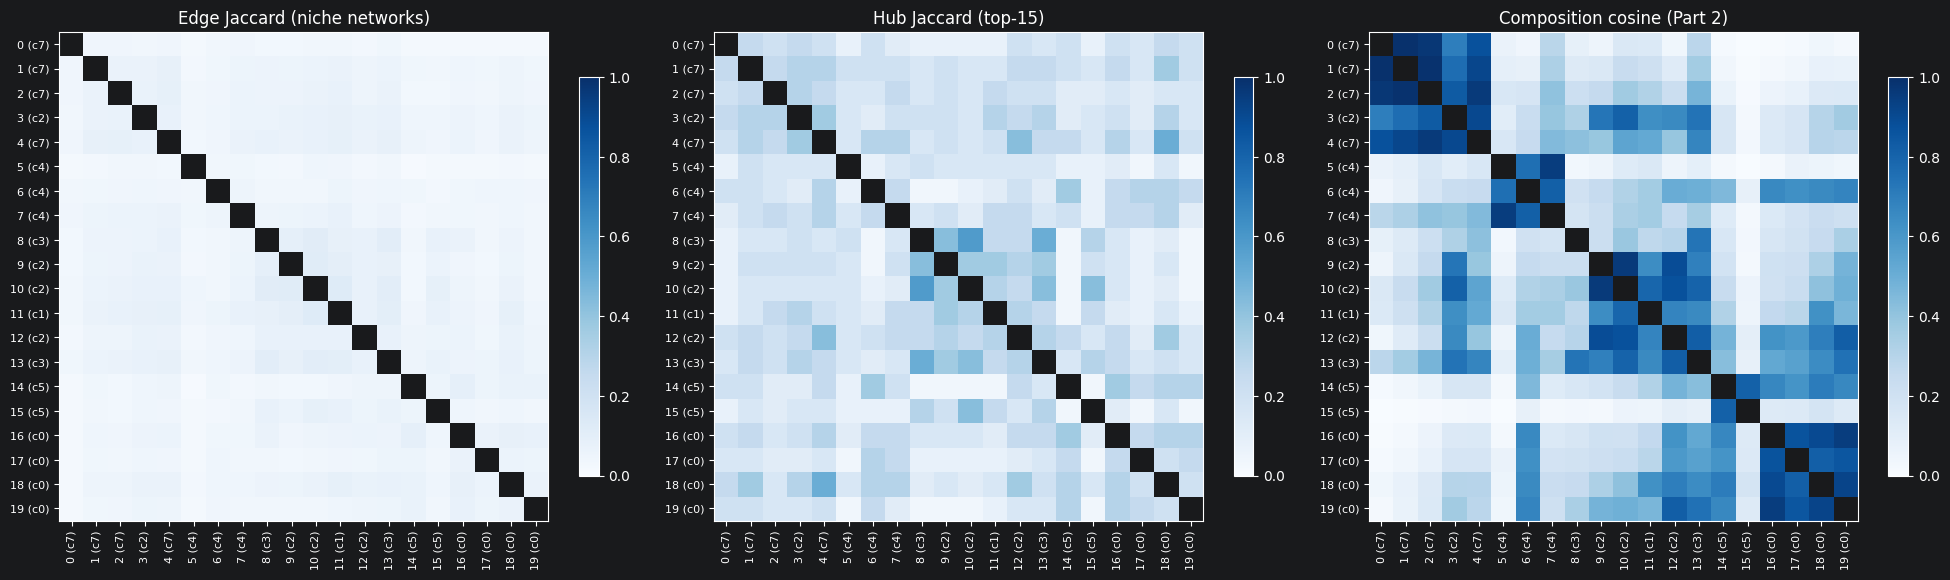

In [14]:
# Visualize the three similarity matrices
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Make labels showing niche_id + dominant class
labels = [f"{nid} (c{int(niche_centroids.loc[nid, 'dominant_class'])})"
          for nid in range(N_NICHES)]

for ax, mat, title in zip(
    axes,
    [edge_jaccard_n, hub_jaccard_n, comp_cos],
    ["Edge Jaccard (niche networks)",
     "Hub Jaccard (top-15)",
     "Composition cosine (Part 2)"],
):
    np.fill_diagonal(mat, np.nan)  # don't show diagonal
    im = ax.imshow(mat, cmap="Blues", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xticks(range(N_NICHES))
    ax.set_yticks(range(N_NICHES))
    ax.set_xticklabels(labels, rotation=90, fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    plt.colorbar(im, ax=ax, shrink=0.7)
    # restore diagonal for downstream use
    np.fill_diagonal(mat, 1.0)

plt.tight_layout()
plt.show()

In [15]:
# Quantify: does edge-similar imply composition-similar?
# Correlation of off-diagonal entries between the three distance matrices.
from scipy.stats import spearmanr

triu = np.triu(np.ones((N_NICHES, N_NICHES), dtype=bool), k=1)
edge_off = edge_jaccard_n[triu]
hub_off = hub_jaccard_n[triu]
comp_off = comp_cos[triu]

print("Spearman correlations (off-diagonal):")
print(f"  edge_jaccard  vs  composition_cosine: ρ = {spearmanr(edge_off, comp_off)[0]:.3f}")
print(f"  hub_jaccard   vs  composition_cosine: ρ = {spearmanr(hub_off, comp_off)[0]:.3f}")
print(f"  edge_jaccard  vs  hub_jaccard:        ρ = {spearmanr(edge_off, hub_off)[0]:.3f}")

Spearman correlations (off-diagonal):
  edge_jaccard  vs  composition_cosine: ρ = 0.615
  hub_jaccard   vs  composition_cosine: ρ = 0.400
  edge_jaccard  vs  hub_jaccard:        ρ = 0.636


### 4b. Hierarchical clustering — do gene networks recover Part 2's niche families?

Cluster the 20 niches by (a) edge Jaccard, (b) hub Jaccard, (c) composition cosine, at K=8. Compare each clustering to Part 2's 8 cell-class families (one per dominant class). Adjusted Rand Index quantifies agreement.

In [16]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.metrics import adjusted_rand_score

K = 8

# Convert similarities to distances
edge_dist = 1.0 - edge_jaccard_n
hub_dist = 1.0 - hub_jaccard_n
comp_dist = 1.0 - comp_cos
# Make sure all diagonals are 0 and matrices are symmetric (numerical artifacts)
for D in (edge_dist, hub_dist, comp_dist):
    np.fill_diagonal(D, 0.0)
    D[:] = (D + D.T) / 2

# Hierarchical clustering on each
def cluster_at_K(D, K, method="average"):
    """Average-linkage hierarchical clustering, cut to K clusters."""
    cond = squareform(D, checks=False)
    Z = linkage(cond, method=method)
    return fcluster(Z, t=K, criterion="maxclust"), Z

edge_clusters, edge_Z = cluster_at_K(edge_dist, K)
hub_clusters, hub_Z = cluster_at_K(hub_dist, K)
comp_clusters, comp_Z = cluster_at_K(comp_dist, K)

# Ground truth: Part 2's 8 cell-class families (dominant_class)
truth_families = niche_centroids.loc[range(N_NICHES), "dominant_class"].values

# Adjusted Rand Index for each
ari_edge = adjusted_rand_score(truth_families, edge_clusters)
ari_hub = adjusted_rand_score(truth_families, hub_clusters)
ari_comp = adjusted_rand_score(truth_families, comp_clusters)

print(f"Adjusted Rand Index vs Part 2's 8 cell-class families:")
print(f"  composition cosine clustering: ARI = {ari_comp:.3f}  (sanity check; should be high)")
print(f"  hub Jaccard clustering:        ARI = {ari_hub:.3f}")
print(f"  edge Jaccard clustering:       ARI = {ari_edge:.3f}")

# Per-niche cluster assignments
print("\nPer-niche cluster assignments (1-8):")
display_df = pd.DataFrame({
    "niche": range(N_NICHES),
    "dom_class": truth_families,
    "comp_cluster": comp_clusters,
    "hub_cluster": hub_clusters,
    "edge_cluster": edge_clusters,
})
print(display_df.to_string(index=False))

Adjusted Rand Index vs Part 2's 8 cell-class families:
  composition cosine clustering: ARI = 0.802  (sanity check; should be high)
  hub Jaccard clustering:        ARI = 0.054
  edge Jaccard clustering:       ARI = 0.250

Per-niche cluster assignments (1-8):
 niche  dom_class  comp_cluster  hub_cluster  edge_cluster
     0          7             1            6             7
     1          7             1            3             3
     2          7             1            5             3
     3          2             1            3             3
     4          7             1            3             3
     5          4             2            8             8
     6          4             2            1             6
     7          4             2            4             5
     8          3             8            7             4
     9          2             5            7             4
    10          2             5            7             4
    11          1             7 

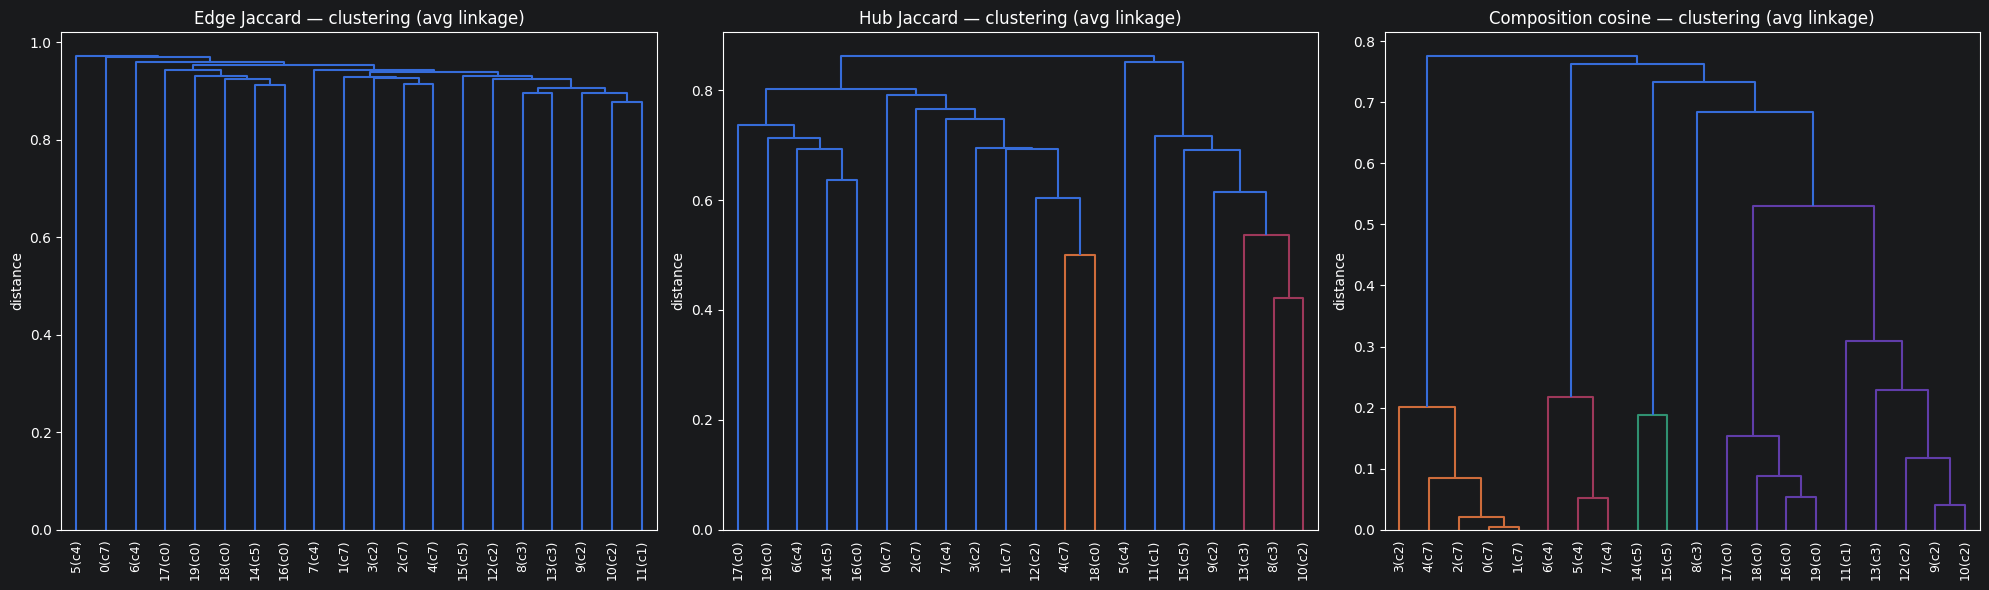

In [17]:
# Visualize the three dendrograms
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

labels = [f"{nid}(c{int(niche_centroids.loc[nid, 'dominant_class'])})"
          for nid in range(N_NICHES)]

for ax, Z, name in zip(
    axes,
    [edge_Z, hub_Z, comp_Z],
    ["Edge Jaccard", "Hub Jaccard", "Composition cosine"]
):
    dendrogram(Z, labels=labels, ax=ax, leaf_rotation=90, leaf_font_size=9)
    ax.set_title(f"{name} — clustering (avg linkage)")
    ax.set_ylabel("distance")

plt.tight_layout()
plt.show()

## 5. Patient coverage and network similarity

For each pair of niches, compute Jaccard overlap on their *patient sets* (which patients have cells in that niche), and check correlation with the edge/hub Jaccard. If patient overlap drives network similarity, our networks reflect cohort effects rather than biology. If patient overlap is independent of network similarity, the networks reflect real cell-type and microenvironment biology.

Spearman correlations involving patient-set Jaccard:

  patient_jaccard  vs  edge_jaccard:        ρ = 0.419
  patient_jaccard  vs  hub_jaccard:         ρ = 0.367
  patient_jaccard  vs  composition_cosine:  ρ = 0.575

Recall: edge_jaccard vs composition: 0.615


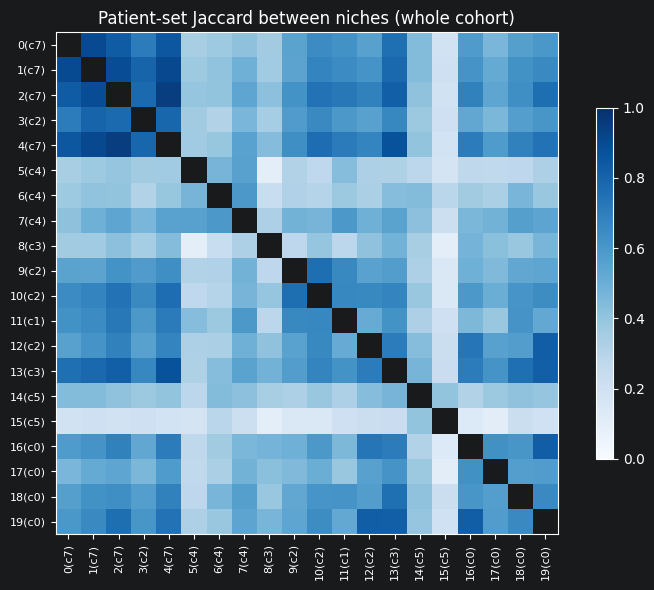

In [18]:
# Patient set per niche (over the full cohort, not just train)
all_niche_assignments = niche_per_cell
niche_patient_sets = {}
for nid in range(N_NICHES):
    cells = np.where(all_niche_assignments == nid)[0]
    patient_set = set(int(p) for p in np.unique(G.patient[cells]))
    niche_patient_sets[nid] = patient_set

# Pairwise Jaccard on patient sets
pat_jaccard = np.zeros((N_NICHES, N_NICHES))
for i in range(N_NICHES):
    for j in range(N_NICHES):
        si, sj = niche_patient_sets[i], niche_patient_sets[j]
        inter = len(si & sj)
        union = len(si | sj)
        pat_jaccard[i, j] = inter / union if union > 0 else 0.0

# Correlations with edge/hub Jaccard
triu = np.triu(np.ones((N_NICHES, N_NICHES), dtype=bool), k=1)
pat_off = pat_jaccard[triu]

print("Spearman correlations involving patient-set Jaccard:\n")
print(f"  patient_jaccard  vs  edge_jaccard:        ρ = {spearmanr(pat_off, edge_off)[0]:.3f}")
print(f"  patient_jaccard  vs  hub_jaccard:         ρ = {spearmanr(pat_off, hub_off)[0]:.3f}")
print(f"  patient_jaccard  vs  composition_cosine:  ρ = {spearmanr(pat_off, comp_off)[0]:.3f}")
print()
print(f"Recall: edge_jaccard vs composition: {spearmanr(edge_off, comp_off)[0]:.3f}")

# Visualize patient Jaccard alongside the others
fig, ax = plt.subplots(figsize=(8, 6))
labels = [f"{nid}(c{int(niche_centroids.loc[nid, 'dominant_class'])})" for nid in range(N_NICHES)]
P = pat_jaccard.copy()
np.fill_diagonal(P, np.nan)
im = ax.imshow(P, cmap="Blues", vmin=0, vmax=1)
ax.set_title("Patient-set Jaccard between niches (whole cohort)")
ax.set_xticks(range(N_NICHES))
ax.set_yticks(range(N_NICHES))
ax.set_xticklabels(labels, rotation=90, fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
plt.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout()
plt.show()

In [19]:
# Persist Part 5 cross-comparison artifacts
part5_artifacts = {
    "alpha": ALPHA,
    "n_common_genes": n_common,
    "n_niches": N_NICHES,
    "niche_summary": niche_summary.to_dict(orient="records"),
    "edge_jaccard": edge_jaccard_n,
    "hub_jaccard": hub_jaccard_n,
    "comp_cos": comp_cos,
    "pat_jaccard": pat_jaccard,
    "spearman_correlations": {
        "edge_vs_comp": float(spearmanr(edge_off, comp_off)[0]),
        "hub_vs_comp": float(spearmanr(hub_off, comp_off)[0]),
        "edge_vs_hub": float(spearmanr(edge_off, hub_off)[0]),
        "pat_vs_edge": float(spearmanr(pat_off, edge_off)[0]),
        "pat_vs_hub": float(spearmanr(pat_off, hub_off)[0]),
        "pat_vs_comp": float(spearmanr(pat_off, comp_off)[0]),
    },
    "ari": {
        "comp_vs_dom_class": float(ari_comp),
        "hub_vs_dom_class": float(ari_hub),
        "edge_vs_dom_class": float(ari_edge),
    },
    "cluster_assignments": {
        "comp": comp_clusters.tolist(),
        "hub": hub_clusters.tolist(),
        "edge": edge_clusters.tolist(),
    },
    "patient_sets_per_niche": {nid: sorted(list(s)) for nid, s in niche_patient_sets.items()},
}
artifacts_file = ggm5_cache / "part5_summary.pkl"
with open(artifacts_file, "wb") as f:
    pickle.dump(part5_artifacts, f)
print(f"saved {artifacts_file} ({artifacts_file.stat().st_size/1e3:.1f} kB)")

# Niche hub table CSV (matching Part 4's)
hub_df = pd.DataFrame({
    f"niche_{nid}": [s for s, _ in sorted(
        [(common_gene_symbols[i], niche_ggms[nid]["degree"][i])
         for i in niche_ggms[nid]["degree"].argsort()[::-1][:15]],
        key=lambda x: -x[1])]
    for nid in range(N_NICHES)
})
hub_df.to_csv(ggm5_cache / "niche_hubs_top15.csv", index=False)
print(f"saved {ggm5_cache / 'niche_hubs_top15.csv'}")

saved ../cache/ggm_niches/part5_summary.pkl (16.7 kB)
saved ../cache/ggm_niches/niche_hubs_top15.csv
